In [17]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal
import random
import re
import string

In [4]:
# random password generator
class GeneratePassword(TypedDict):
    user_password: str 
    valid_invalid_password: Literal["valid", "invalid"]
    iteration: int
    max_iteration: int

In [27]:
def validatePassword(state: GeneratePassword) -> GeneratePassword:
    # Validate password based on rules:
    # Minimum 8 characters
    # At least 1 uppercase letter
    # At least 1 number
    # At least 1 special character
    password = state['user_password']
    if len(password) >= 8:
      if len([char  for char in password if char.isalpha()]):
        if len([char  for char in password if char.isnumeric()]):
            if bool(re.search(r'[^a-zA-Z0-9\s]', password)):
               return {"valid_invalid_password": "valid"}
    return {"valid_invalid_password": "invalid"}       
         
def generatePassword(state: GeneratePassword) -> GeneratePassword:
    characters = string.ascii_letters + string.digits + string.punctuation
    password = ''.join(random.choices(characters, k=9))
    return {"user_password": password, "iteration": state["iteration"] + 1}

def check_conditions(state: GeneratePassword):
    if state["valid_invalid_password"] == "valid" and state["iteration"] <= state["max_iteration"]:
      return "valid"
    return "invalid"

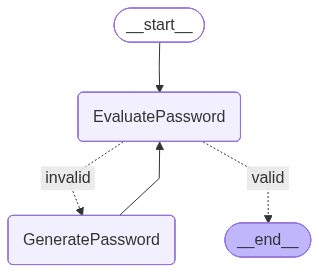

In [28]:
graph = StateGraph(GeneratePassword)

graph.add_node("EvaluatePassword", validatePassword)
graph.add_node("GeneratePassword", generatePassword)

graph.add_edge(START, "EvaluatePassword")
graph.add_conditional_edges("EvaluatePassword", check_conditions, {"valid": END, "invalid": "GeneratePassword"})
graph.add_edge("GeneratePassword","EvaluatePassword")

workflow = graph.compile()
workflow

In [32]:
workflow.invoke({"user_password":"Abc@123", "iteration":1, "max_iteration":5})

{'user_password': 'Ho"L|59b+',
 'valid_invalid_password': 'valid',
 'iteration': 4,
 'max_iteration': 5}

In [30]:
workflow.invoke({"user_password":"avc", "iteration":1, "max_iteration":5})

{'user_password': '*gaC89Yfh',
 'valid_invalid_password': 'valid',
 'iteration': 3,
 'max_iteration': 5}

In [31]:
workflow.invoke({"user_password":"abc@123as32", "iteration":1, "max_iteration":5})

{'user_password': 'abc@123as32',
 'valid_invalid_password': 'valid',
 'iteration': 1,
 'max_iteration': 5}